In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/income.csv")

In [4]:
X = df[['Age','Income($)']].copy()
X.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


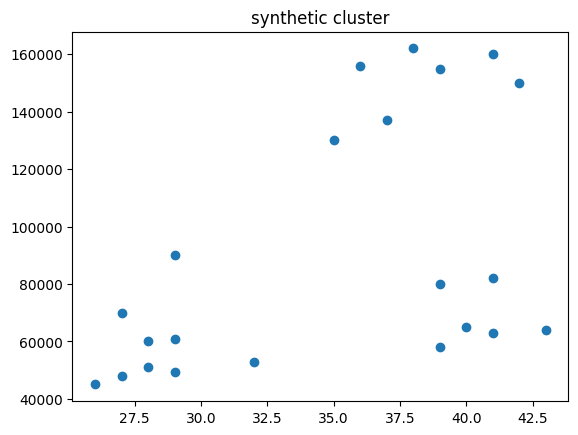

In [5]:
plt.scatter(X['Age'],X['Income($)'])
plt.title("synthetic cluster")
plt.show()

In [14]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
# Pass both columns in together
scaled_data = scale.fit_transform(df[['Age', 'Income($)']])

# Assign them back to X
X = pd.DataFrame(scaled_data, columns=['Age', 'Income($)'])
X.head(5)

,Age,Income($)
0,0.058824,0.213675
1,0.176471,0.384615
2,0.176471,0.136752
3,0.117647,0.128205
4,0.941176,0.897436


In [7]:
from pyclustering.cluster.kmedians import kmedians
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
import warnings
np.warnings = warnings
# Explicit Initialization Phase
# Calculate optimal starting points for the medians
initializer = kmeans_plusplus_initializer(X, 3)
initial_medians = initializer.initialize()

# Model Instantiation and Execution Phase
# Pass the data and the starting medians into the algorithm
kmedians_instance = kmedians(X, initial_medians)
kmedians_instance.process()

# Extraction Phase
# Retrieve the results
clusters = kmedians_instance.get_clusters() # Returns list of index lists
final_medians = kmedians_instance.get_medians()

In [8]:
final_medians

[[0.8529411764705883, 0.16239316239316243],
 [0.11764705882352944, 0.12820512820512825],
 [0.7058823529411766, 1.0000000000000002]]

In [10]:
# 1. Extract the correct lists of indices from your executed model
clusters_list = kmedians_instance.get_clusters() 
# 2. Initialize the empty array
cluster_labels = np.zeros(len(X), dtype=int)
final_medians = np.array(final_medians)

# 3. Loop through the correct variable (clusters_list)
for cluster_id, row_indices in enumerate(clusters_list):
    # row_indices is now correctly a list of integers (e.g., [0, 5, 12])
    cluster_labels[row_indices] = cluster_id

# 4. Map back to your original DataFrame
df['cluster'] = cluster_labels

In [11]:
df.head(5)

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,2


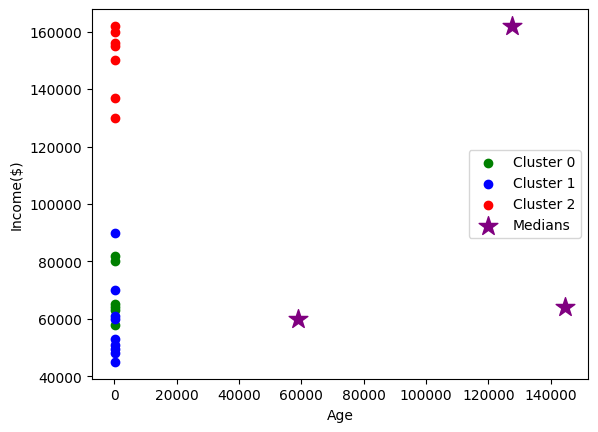

In [13]:
# Inverse transform the scaled medians back to their original values
medians_unscaled = scale.inverse_transform(final_medians)

dfx = df
df1 = dfx[dfx.cluster == 0]
df2 = dfx[dfx.cluster == 1]
df3 = dfx[dfx.cluster == 2]

plt.scatter(df1.Age, df1['Income($)'], color='green', label='Cluster 0')
plt.scatter(df2.Age, df2['Income($)'], color='blue', label='Cluster 1')
plt.scatter(df3.Age, df3['Income($)'], color='red', label='Cluster 2')

# Plot the unscaled medians (added s=200 to make the stars larger and easier to see)
plt.scatter(medians_unscaled[:,0], medians_unscaled[:,1], color='purple', marker='*', s=200, label='Medians')

plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()
plt.show()